# Regression Confidence and Prediction Intervals

In the univariate notebook we built confidence and prediction intervals for $Y \sim N(\mu, \sigma^2)$ — a single unknown mean. Now we move to the **regression setting**, where the mean of $Y$ depends on a predictor $x$:

$$Y_i = \alpha + \beta\, x_i + u_i, \qquad u_i \sim N(0, \sigma^2)$$

following the notation in Casella & Berger, Chapter 12.2. The conditional mean $E[Y \mid x] = \alpha + \beta x$ is a line, and everything we did in the univariate case generalizes:

- A **confidence interval** at a given $x_0$ captures uncertainty about **where the regression line is** — i.e., the conditional mean $\alpha + \beta x_0$.
- A **prediction interval** at a given $x_0$ captures that *plus* the scatter of an individual observation around the line.

As before, we proceed in two parts:

1. **Part 1 — Known $\sigma$.** We use $z$-scores and the true $\sigma$ to build the intervals by hand, so you can see exactly where each piece comes from.
2. **Part 2 — Unknown $\sigma$.** We estimate $\sigma$ from the residuals and use the $t$-distribution. This is the real-world case, and we use `statsmodels` to compute it.

**Key notation (Casella & Berger):**

| Symbol | Meaning |
|---|---|
| $\alpha,\, \beta$ | True intercept and slope |
| $\hat{\alpha},\, \hat{\beta}$ | OLS estimates |
| $S_{xx} = \sum_{i=1}^n (x_i - \bar{x})^2$ | Sum of squared deviations of $x$ |
| $S^2 = \frac{1}{n-2}\sum_{i=1}^n (Y_i - \hat{\alpha} - \hat{\beta}x_i)^2$ | Residual variance estimator |
| $S$ | Residual standard error |

In [1]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import norm, t

## Simulating the data

We generate data from a known DGP so we can compare our intervals against the truth:

$$Y = \alpha + \beta\, x + u, \qquad \alpha = -30,\; \beta = 3, \qquad x \sim N(10, 4), \quad u \sim N(0, \sigma^2),\; \sigma = 8$$

We split into 150 training observations (to estimate the model) and 150 test observations (to visualize coverage).

In [2]:
# True parameters
alpha_true = -30
beta_true = 3
sigma_known = 8.0

# Simulate
np.random.seed(77)
n_total = 300
x_all = np.random.normal(10, 2, n_total)
u_all = np.random.normal(0, sigma_known, n_total)
y_all = alpha_true + beta_true * x_all + u_all

# Train/test split
n = 150
x_train, x_test = x_all[:n], x_all[n:]
y_train, y_test = y_all[:n], y_all[n:]

print(f"True DGP:  Y = {alpha_true} + {beta_true}·x + u,  σ = {sigma_known}")
print(f"Training:  {n} obs")
print(f"Test:      {len(x_test)} obs")

True DGP:  Y = -30 + 3·x + u,  σ = 8.0
Training:  150 obs
Test:      150 obs


## OLS estimation

We estimate the regression on the training data. The OLS estimates $\hat{\alpha}, \hat{\beta}$ give us the fitted line $\hat{Y} = \hat{\alpha} + \hat{\beta}\, x$. We also compute $S_{xx} = \sum_{i=1}^n (x_i - \bar{x})^2$, which controls how the width of the bands varies with $x_0$.

In [3]:
# OLS on training data
X_train = sm.add_constant(x_train)
model = sm.OLS(y_train, X_train).fit()

alpha_hat, beta_hat = model.params
x_bar = x_train.mean()
S_xx = np.sum((x_train - x_bar)**2)

print(f"Estimated:  Ŷ = {alpha_hat:.2f} + {beta_hat:.2f}·x")
print(f"True:       Y = {alpha_true} + {beta_true}·x")
print(f"\nx̄    = {x_bar:.3f}")
print(f"S_xx = {S_xx:.2f}")
print(f"S    = {np.sqrt(model.mse_resid):.3f}   (true σ = {sigma_known})")

Estimated:  Ŷ = -31.89 + 3.22·x
True:       Y = -30 + 3·x

x̄    = 9.890
S_xx = 566.74
S    = 8.412   (true σ = 8.0)


# --- Part 1: Known $\sigma$ ($z$-scores) ---

## The formulas (Casella & Berger, §12.2.5)

Casella & Berger (12.2.34) show that the estimator of the conditional mean at $x_0$ has a normal distribution:

$$\hat{\alpha} + \hat{\beta}\,x_0 \;\sim\; N\!\left(\alpha + \beta x_0,\;\; \sigma^2\!\left(\frac{1}{n} + \frac{(x_0 - \bar{x})^2}{S_{xx}}\right)\right)$$

where $S_{xx} = \sum_{i=1}^n (x_i - \bar{x})^2$.

When $\sigma$ is known, this gives us the **confidence interval** for $\alpha + \beta x_0$ (equation 12.2.35):

$$\hat{\alpha} + \hat{\beta}\,x_0 \;\pm\; z_{\alpha/2}\;\sigma\,\sqrt{\frac{1}{n} + \frac{(x_0 - \bar{x})^2}{S_{xx}}}$$

For the **prediction interval** for a new observation $Y_0$ at $x = x_0$ (equation 12.2.36), the variance of $Y_0 - (\hat{\alpha} + \hat{\beta}\,x_0)$ adds the irreducible $\sigma^2$:

$$\hat{\alpha} + \hat{\beta}\,x_0 \;\pm\; z_{\alpha/2}\;\sigma\,\sqrt{1 + \frac{1}{n} + \frac{(x_0 - \bar{x})^2}{S_{xx}}}$$

Notice the "$1 +$" inside the square root — the same "$1$" as in the univariate case. The term $(x_0 - \bar{x})^2 / S_{xx}$ is what makes the bands flare out away from $\bar{x}$: you are most certain about the line where you have the most data.

In [4]:
z_crit = norm.ppf(0.975)

# Evaluate bands on a fine grid of x values (sorted, for smooth curves)
x_grid = np.linspace(x_test.min() - 1, x_test.max() + 1, 200)
y_hat_grid = alpha_hat + beta_hat * x_grid

# The Casella & Berger term: 1/n + (x_0 - x_bar)^2 / S_xx
h_grid = 1/n + (x_grid - x_bar)**2 / S_xx

# CI band (known sigma, eq. 12.2.35)
ci_half_z = z_crit * sigma_known * np.sqrt(h_grid)
ci_lower_z = y_hat_grid - ci_half_z
ci_upper_z = y_hat_grid + ci_half_z

# PI band (known sigma, eq. 12.2.36)
pi_half_z = z_crit * sigma_known * np.sqrt(1 + h_grid)
pi_lower_z = y_hat_grid - pi_half_z
pi_upper_z = y_hat_grid + pi_half_z

print(f"z critical value: {z_crit:.4f}")
print(f"\nAt x₀ = x̄ = {x_bar:.2f}:")
h_at_xbar = 1/n + 0  # (x_0 - x_bar)^2 / S_xx = 0
print(f"  1/n + (x₀ - x̄)²/S_xx = 1/{n} = {h_at_xbar:.5f}")
print(f"  CI half-width = z·σ·√(1/n)          = {z_crit * sigma_known * np.sqrt(h_at_xbar):.3f}")
print(f"  PI half-width = z·σ·√(1 + 1/n)      = {z_crit * sigma_known * np.sqrt(1 + h_at_xbar):.3f}")

z critical value: 1.9600

At x₀ = x̄ = 9.89:
  1/n + (x₀ - x̄)²/S_xx = 1/150 = 0.00667
  CI half-width = z·σ·√(1/n)          = 1.280
  PI half-width = z·σ·√(1 + 1/n)      = 15.732


## Visualizing the difference (known $\sigma$)

Four-panel build-up. The bands are smooth curves because we evaluate them on a fine grid of $x$ values. In panel (d), test observations outside the prediction band are marked in red.

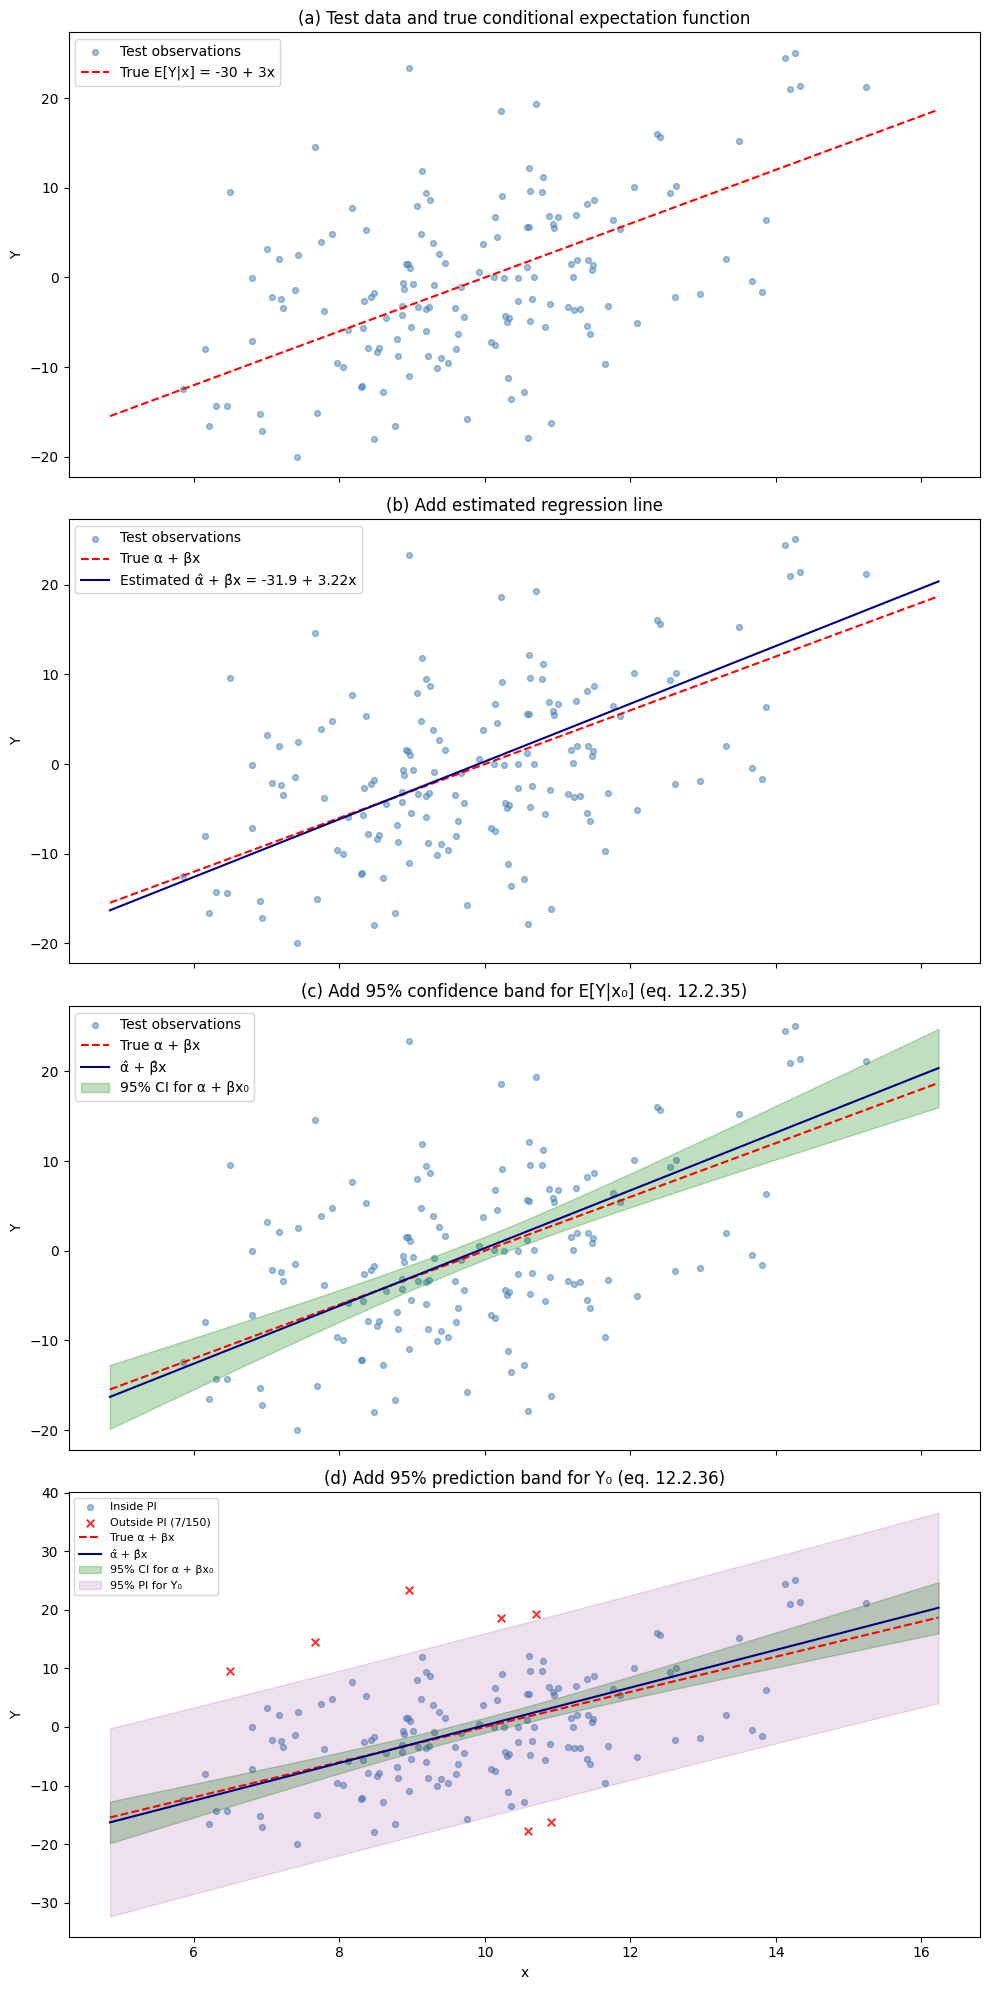

In [5]:
# Classify test points as inside/outside the z-based PI
X_test_const = sm.add_constant(x_test)
y_hat_test = alpha_hat + beta_hat * x_test
h_test = 1/n + (x_test - x_bar)**2 / S_xx
pi_lower_test_z = y_hat_test - z_crit * sigma_known * np.sqrt(1 + h_test)
pi_upper_test_z = y_hat_test + z_crit * sigma_known * np.sqrt(1 + h_test)
inside_z = (y_test >= pi_lower_test_z) & (y_test <= pi_upper_test_z)
n_outside_z = (~inside_z).sum()

# True conditional expectation on the grid
y_true_grid = alpha_true + beta_true * x_grid

fig, axes = plt.subplots(4, 1, figsize=(10, 20), sharex=True)

# Panel (a): test data + true CEF
axes[0].scatter(x_test, y_test, s=18, alpha=0.5, color='steelblue', label='Test observations')
axes[0].plot(x_grid, y_true_grid, 'r--', lw=1.5,
             label=f'True E[Y|x] = {alpha_true} + {beta_true}x')
axes[0].set_title('(a) Test data and true conditional expectation function')
axes[0].legend()

# Panel (b): + estimated regression line
axes[1].scatter(x_test, y_test, s=18, alpha=0.5, color='steelblue', label='Test observations')
axes[1].plot(x_grid, y_true_grid, 'r--', lw=1.5, label='True α + βx')
axes[1].plot(x_grid, y_hat_grid, 'navy', lw=1.5,
             label=f'Estimated α̂ + β̂x = {alpha_hat:.1f} + {beta_hat:.2f}x')
axes[1].set_title('(b) Add estimated regression line')
axes[1].legend()

# Panel (c): + CI band
axes[2].scatter(x_test, y_test, s=18, alpha=0.5, color='steelblue', label='Test observations')
axes[2].plot(x_grid, y_true_grid, 'r--', lw=1.5, label='True α + βx')
axes[2].plot(x_grid, y_hat_grid, 'navy', lw=1.5, label='α̂ + β̂x')
axes[2].fill_between(x_grid, ci_lower_z, ci_upper_z, alpha=0.25, color='green',
                     label='95% CI for α + βx₀')
axes[2].set_title('(c) Add 95% confidence band for E[Y|x₀] (eq. 12.2.35)')
axes[2].legend()

# Panel (d): + PI band with inside/outside dots
axes[3].scatter(x_test[inside_z], y_test[inside_z], s=18, alpha=0.5, color='steelblue',
                label='Inside PI')
axes[3].scatter(x_test[~inside_z], y_test[~inside_z], s=30, alpha=0.8, color='red',
                marker='x', label=f'Outside PI ({n_outside_z}/{len(y_test)})')
axes[3].plot(x_grid, y_true_grid, 'r--', lw=1.5, label='True α + βx')
axes[3].plot(x_grid, y_hat_grid, 'navy', lw=1.5, label='α̂ + β̂x')
axes[3].fill_between(x_grid, ci_lower_z, ci_upper_z, alpha=0.25, color='green',
                     label='95% CI for α + βx₀')
axes[3].fill_between(x_grid, pi_lower_z, pi_upper_z, alpha=0.12, color='purple',
                     label='95% PI for Y₀')
axes[3].set_title('(d) Add 95% prediction band for Y₀ (eq. 12.2.36)')
axes[3].legend(fontsize=8)

for ax in axes:
    ax.set_ylabel('Y')
axes[3].set_xlabel('x')

plt.tight_layout()
plt.show()

# --- Part 2: Unknown $\sigma$ ($t$-distribution) ---

## What changes (Casella & Berger, §12.2.5 continued)

When $\sigma$ is unknown we replace it with the residual standard error $S$:

$$S = \sqrt{\frac{1}{n-2}\sum_{i=1}^n (Y_i - \hat{\alpha} - \hat{\beta}\,x_i)^2}$$

(We lose two degrees of freedom — one for $\alpha$, one for $\beta$.) The pivot becomes a $t_{n-2}$ instead of a standard normal.

**Confidence interval** for $\alpha + \beta x_0$ (eq. 12.2.35 with $S$ replacing $\sigma$):

$$\hat{\alpha} + \hat{\beta}\,x_0 \;\pm\; t_{n-2,\,\alpha/2}\; S\,\sqrt{\frac{1}{n} + \frac{(x_0 - \bar{x})^2}{S_{xx}}}$$

**Prediction interval** for $Y_0$ (eq. 12.2.36 with $S$ replacing $\sigma$):

$$\hat{\alpha} + \hat{\beta}\,x_0 \;\pm\; t_{n-2,\,\alpha/2}\; S\,\sqrt{1 + \frac{1}{n} + \frac{(x_0 - \bar{x})^2}{S_{xx}}}$$

In practice we let `statsmodels` compute these via `get_prediction()`, which handles the algebra for us.

In [6]:
S = np.sqrt(model.mse_resid)
df = int(model.df_resid)  # n - 2
t_crit = t.ppf(0.975, df)

print(f"Residual std error:  S = {S:.3f}   (true σ = {sigma_known})")
print(f"Degrees of freedom:  n - 2 = {df}")
print(f"t critical value:    t_{{0.025, {df}}} = {t_crit:.4f}")
print(f"z critical value:    z_{{0.025}}        = {z_crit:.4f}")

Residual std error:  S = 8.412   (true σ = 8.0)
Degrees of freedom:  n - 2 = 148
t critical value:    t_{0.025, 148} = 1.9761
z critical value:    z_{0.025}        = 1.9600


## Computing the bands with `statsmodels`

`model.get_prediction(X)` returns an object whose `.summary_frame()` gives us both the confidence interval (`mean_ci_lower`, `mean_ci_upper`) and the prediction interval (`obs_ci_lower`, `obs_ci_upper`) at each row of `X`.

In [7]:
# Bands on the fine grid (statsmodels needs the design matrix with constant)
X_grid = sm.add_constant(x_grid)
pred_grid = model.get_prediction(X_grid).summary_frame(alpha=0.05)

ci_lower_t = pred_grid['mean_ci_lower'].values
ci_upper_t = pred_grid['mean_ci_upper'].values
pi_lower_t = pred_grid['obs_ci_lower'].values
pi_upper_t = pred_grid['obs_ci_upper'].values

# Bands at each test point (for inside/outside classification)
pred_test = model.get_prediction(X_test_const).summary_frame(alpha=0.05)
pi_lower_test_t = pred_test['obs_ci_lower'].values
pi_upper_test_t = pred_test['obs_ci_upper'].values
inside_t = (y_test >= pi_lower_test_t) & (y_test <= pi_upper_test_t)
n_outside_t = (~inside_t).sum()

print(f"Test observations outside the 95% PI (t-based): {n_outside_t}/{len(y_test)}")
print(f"Test observations outside the 95% PI (z-based): {n_outside_z}/{len(y_test)}")

Test observations outside the 95% PI (t-based): 7/150
Test observations outside the 95% PI (z-based): 7/150


## Visualizing the difference (unknown $\sigma$)

Same four-panel build-up, now with $t$-based bands computed from estimated $s$.

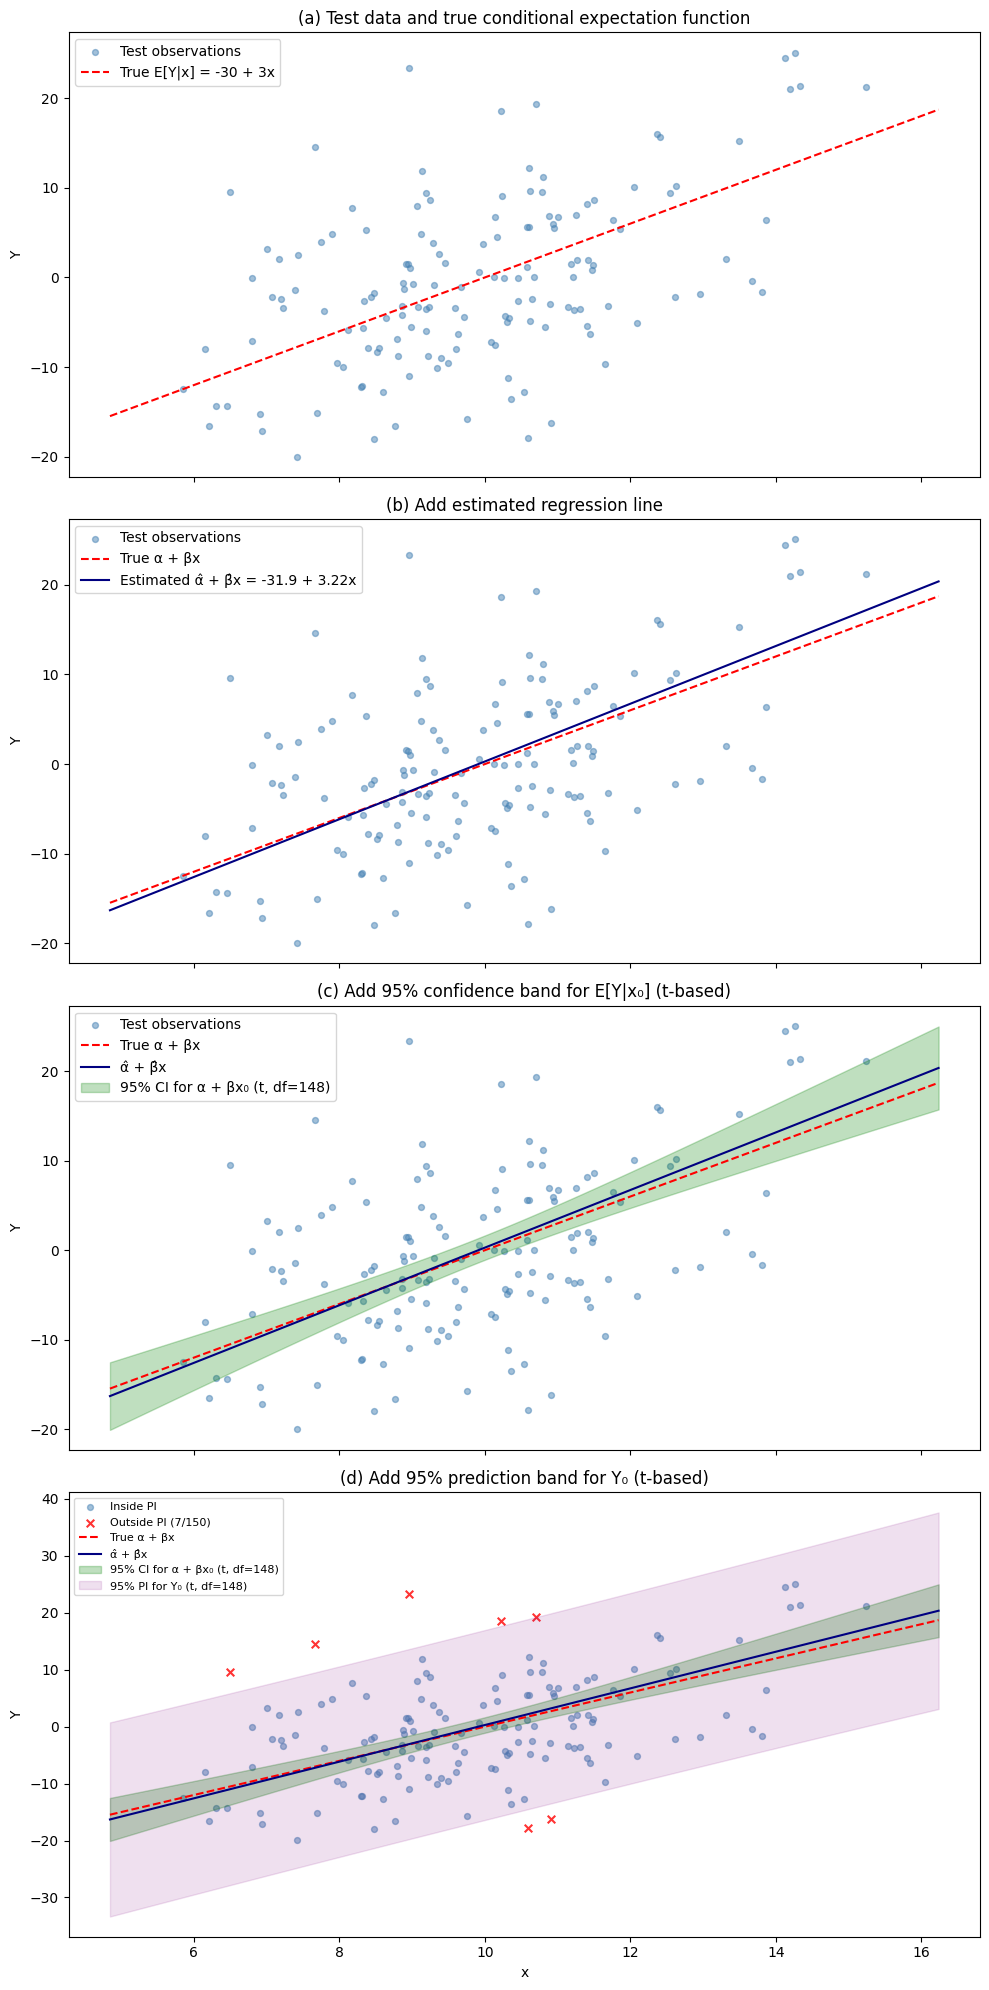

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(10, 20), sharex=True)

# Panel (a): test data + true CEF
axes[0].scatter(x_test, y_test, s=18, alpha=0.5, color='steelblue', label='Test observations')
axes[0].plot(x_grid, y_true_grid, 'r--', lw=1.5,
             label=f'True E[Y|x] = {alpha_true} + {beta_true}x')
axes[0].set_title('(a) Test data and true conditional expectation function')
axes[0].legend()

# Panel (b): + estimated regression line
axes[1].scatter(x_test, y_test, s=18, alpha=0.5, color='steelblue', label='Test observations')
axes[1].plot(x_grid, y_true_grid, 'r--', lw=1.5, label='True α + βx')
axes[1].plot(x_grid, y_hat_grid, 'navy', lw=1.5,
             label=f'Estimated α̂ + β̂x = {alpha_hat:.1f} + {beta_hat:.2f}x')
axes[1].set_title('(b) Add estimated regression line')
axes[1].legend()

# Panel (c): + t-based CI band
axes[2].scatter(x_test, y_test, s=18, alpha=0.5, color='steelblue', label='Test observations')
axes[2].plot(x_grid, y_true_grid, 'r--', lw=1.5, label='True α + βx')
axes[2].plot(x_grid, y_hat_grid, 'navy', lw=1.5, label='α̂ + β̂x')
axes[2].fill_between(x_grid, ci_lower_t, ci_upper_t, alpha=0.25, color='green',
                     label=f'95% CI for α + βx₀ (t, df={df})')
axes[2].set_title('(c) Add 95% confidence band for E[Y|x₀] (t-based)')
axes[2].legend()

# Panel (d): + t-based PI band with inside/outside dots
axes[3].scatter(x_test[inside_t], y_test[inside_t], s=18, alpha=0.5, color='steelblue',
                label='Inside PI')
axes[3].scatter(x_test[~inside_t], y_test[~inside_t], s=30, alpha=0.8, color='red',
                marker='x', label=f'Outside PI ({n_outside_t}/{len(y_test)})')
axes[3].plot(x_grid, y_true_grid, 'r--', lw=1.5, label='True α + βx')
axes[3].plot(x_grid, y_hat_grid, 'navy', lw=1.5, label='α̂ + β̂x')
axes[3].fill_between(x_grid, ci_lower_t, ci_upper_t, alpha=0.25, color='green',
                     label=f'95% CI for α + βx₀ (t, df={df})')
axes[3].fill_between(x_grid, pi_lower_t, pi_upper_t, alpha=0.12, color='purple',
                     label=f'95% PI for Y₀ (t, df={df})')
axes[3].set_title('(d) Add 95% prediction band for Y₀ (t-based)')
axes[3].legend(fontsize=8)

for ax in axes:
    ax.set_ylabel('Y')
axes[3].set_xlabel('x')

plt.tight_layout()
plt.show()

# Summary (Casella & Berger notation)

| | Known $\sigma$ ($z$-based) | Unknown $\sigma$ ($t$-based) |
|---|---|---|
| **Critical value** | $z_{\alpha/2}$ from standard normal | $t_{n-2,\,\alpha/2}$ from $t$-distribution |
| **CI for $\alpha + \beta x_0$** (eq. 12.2.35) | $\hat{\alpha} + \hat{\beta}x_0 \;\pm\; z \cdot \sigma\sqrt{\frac{1}{n} + \frac{(x_0-\bar{x})^2}{S_{xx}}}$ | $\hat{\alpha} + \hat{\beta}x_0 \;\pm\; t \cdot S\sqrt{\frac{1}{n} + \frac{(x_0-\bar{x})^2}{S_{xx}}}$ |
| **PI for $Y_0$** (eq. 12.2.36) | $\hat{\alpha} + \hat{\beta}x_0 \;\pm\; z \cdot \sigma\sqrt{1 + \frac{1}{n} + \frac{(x_0-\bar{x})^2}{S_{xx}}}$ | $\hat{\alpha} + \hat{\beta}x_0 \;\pm\; t \cdot S\sqrt{1 + \frac{1}{n} + \frac{(x_0-\bar{x})^2}{S_{xx}}}$ |

**Three things to remember:**

1. The **confidence band** captures uncertainty about the regression line $\alpha + \beta x_0$. It is narrowest at $x_0 = \bar{x}$ (where $(x_0 - \bar{x})^2/S_{xx} = 0$) and flares out at the edges.
2. The **prediction band** adds the irreducible scatter $\sigma^2$ of individual observations around the line. It is always wider than the confidence band, and it does **not** shrink to zero as $n \to \infty$ — it converges to $\pm z_{\alpha/2}\,\sigma$.
3. Both bands are **wider away from $\bar{x}$**. The term $(x_0 - \bar{x})^2/S_{xx}$ is the regression version of the univariate lesson: estimation uncertainty depends on where you are predicting.